# Clustering Analysis — Hotel Booking Demand

## Objective

The objective of this analysis is to identify meaningful groups of hotel bookings with similar characteristics using an unsupervised clustering method.

### Research question

**Can hotel bookings be grouped into meaningful segments based on booking timing, price, length of stay, number of guests, and special requests? Can hotel bookings be meaningfully grouped into distinct booking profiles based on their characteristics?**

The analysis uses **K-means clustering**.

Different numbers of clusters will be tested and evaluated using:

- the **Elbow Method**,
- the **Silhouette Score**.

The final clustering solution will be visualized and interpreted using cluster centroids.

The target variable `is_canceled` is **not used to create the clusters**, because clustering is an unsupervised learning method.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


In [2]:
from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(filename)

print(f"Loaded file: {filename}")
print(f"Dataset shape: {df.shape}")

display(df.head())

Saving hotel_bookings_clean(1).csv to hotel_bookings_clean(1).csv
Loaded file: hotel_bookings_clean(1).csv
Dataset shape: (119205, 34)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,previous_bookings,room_changed,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,0,2,0,0,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,0,2,0,0,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,1,1,0,1,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,1,1,0,0,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,Transient,98.0,0,1,2,2,0,0,Summer


## 2. Prepare variables for clustering

Two aggregated variables are used:

- `total_nights` — total number of weekend and weekday nights,
- `total_guests` — total number of adults, children and babies.

These variables were created during the preprocessing stage. If they are not present in the uploaded dataset, they are calculated below.

In [3]:
if "total_nights" not in df.columns:
    df["total_nights"] = (
        df["stays_in_weekend_nights"]
        + df["stays_in_week_nights"]
    )

if "total_guests" not in df.columns:
    df["total_guests"] = (
        df["adults"]
        + df["children"]
        + df["babies"]
    )

print("Required derived variables are available.")

Required derived variables are available.


## 3. Feature selection

The following numerical variables are selected for clustering:

- `lead_time` — number of days between booking and scheduled arrival,
- `adr` — average daily rate,
- `total_nights` — total length of stay,
- `total_guests` — total number of guests,
- `total_of_special_requests` — number of special requests.

These variables represent different aspects of booking behaviour and allow the clusters to be interpreted as booking profiles.

The cancellation status is not included in the clustering features.

In [4]:
features = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests",
    "total_of_special_requests"
]

missing_columns = [
    column for column in features
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

cluster_data = df[features].copy()

for column in features:
    cluster_data[column] = pd.to_numeric(
        cluster_data[column],
        errors="coerce"
    )

print("Features used for clustering:")
print(features)

print("\nDataset shape before removing missing values:")
print(cluster_data.shape)

print("\nMissing values:")
print(cluster_data.isna().sum())

Features used for clustering:
['lead_time', 'adr', 'total_nights', 'total_guests', 'total_of_special_requests']

Dataset shape before removing missing values:
(119205, 5)

Missing values:
lead_time                    0
adr                          0
total_nights                 0
total_guests                 0
total_of_special_requests    0
dtype: int64


## 4. Missing values and descriptive statistics

Only observations with complete values for all selected clustering variables are used.

Descriptive statistics are displayed to understand the scale and distribution of the selected variables before clustering.

In [5]:
cluster_data = cluster_data.dropna().copy()

print("Observations used for clustering:", len(cluster_data))

display(
    cluster_data.describe().T
)

Observations used for clustering: 119205


,count,mean,std,min,25%,50%,75%,max
lead_time,119205.0,104.111858,106.875761,0.0,18.0,69.00,161.0,737.0
adr,119205.0,101.972428,50.432101,0.0,69.5,94.95,126.0,5400.0
total_nights,119205.0,3.426207,2.540637,0.0,2.0,3.00,4.0,69.0
total_guests,119205.0,1.971201,0.718885,1.0,2.0,2.00,2.0,55.0
total_of_special_requests,119205.0,0.571486,0.792877,0.0,0.0,0.00,1.0,5.0


In [6]:
profile_data = df.loc[cluster_data.index].copy()

print(
    "Observations available for cluster profiling:",
    len(profile_data)
)

Observations available for cluster profiling: 119205


## 5. Standardization

K-means clustering is based on distances between observations.

The selected variables are measured on different scales. For example, `lead_time` may contain hundreds of days, whereas `total_guests` usually contains only a few persons.

Therefore, the variables are standardized using `StandardScaler`.

After standardization, each variable has approximately:

- mean = 0,
- standard deviation = 1.

This prevents variables with larger numerical scales from dominating the clustering process.

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    cluster_data[features]
)

print("Mean after standardization:")
print(
    np.round(X_scaled.mean(axis=0), 4)
)

print("\nStandard deviation after standardization:")
print(
    np.round(X_scaled.std(axis=0), 4)
)

Mean after standardization:
[ 0.  0. -0.  0. -0.]

Standard deviation after standardization:
[1. 1. 1. 1. 1.]


# K-means clustering

## 6. Testing different numbers of clusters

At least five different clustering solutions should be evaluated.

In this analysis, the following numbers of clusters are tested:

**K = 2, 3, 4, 5, 6, 7**

For every value of K, two measures are calculated:

### Inertia

Inertia represents the within-cluster sum of squared distances.

Lower values indicate more compact clusters. However, inertia naturally decreases when the number of clusters increases.

Therefore, the **Elbow Method** is used to identify the point after which adding additional clusters provides only a relatively small improvement.

### Silhouette Score

The Silhouette Score evaluates both cluster cohesion and separation.

Values closer to **1** indicate better-separated clusters, values around **0** indicate overlapping clusters, and negative values may indicate incorrect cluster assignments.

In [8]:
K_values = range(2, 8)

results = []

silhouette_sample_size = min(
    10000,
    len(X_scaled)
)

for k in K_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=silhouette_sample_size,
        random_state=RANDOM_STATE
    )

    results.append({
        "K": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette
    })

k_results = pd.DataFrame(results)

display(
    k_results.round(4)
)

,K,Inertia,Silhouette Score
0,2,484828.2198,0.2520
1,3,406955.0300,0.2345
2,4,357974.5740,0.2337
3,5,312021.7093,0.2523
4,6,286182.7684,0.2471
5,7,267837.3935,0.2338


## 7. Elbow Method

The Elbow Method is used to examine how inertia changes as the number of clusters increases.

The preferred number of clusters is typically located around the point where the decrease in inertia begins to slow noticeably.

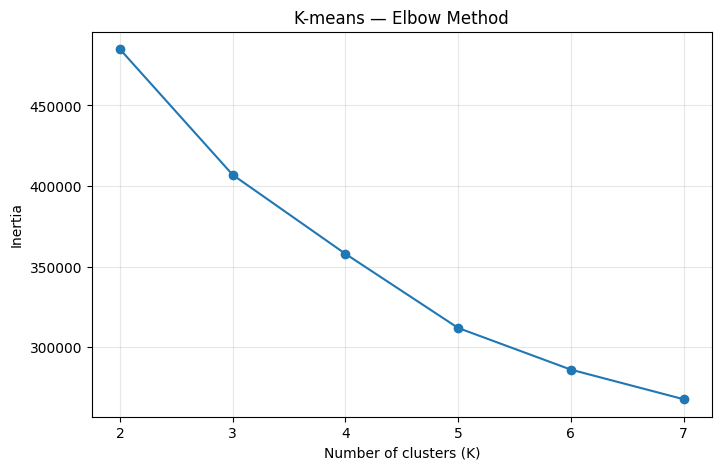

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results["K"],
    k_results["Inertia"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("K-means — Elbow Method")

plt.xticks(list(K_values))
plt.grid(alpha=0.3)

plt.show()

## 8. Silhouette Score

The Silhouette Score is used as an additional measure for selecting the number of clusters.

A higher Silhouette Score indicates that observations are better matched to their own cluster and more separated from other clusters.

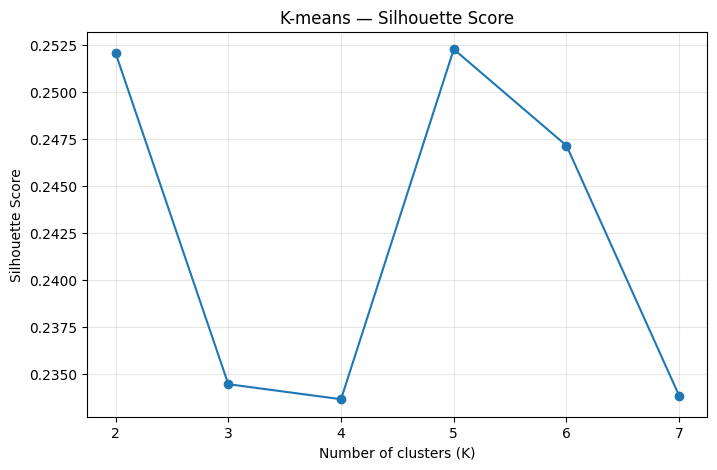

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_results["K"],
    k_results["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-means — Silhouette Score")

plt.xticks(list(K_values))
plt.grid(alpha=0.3)

plt.show()

## 9. Selection of the final number of clusters

The final number of clusters is selected primarily using the highest Silhouette Score.

The result should also be considered together with the Elbow Method plot to verify whether the selected solution provides a reasonable balance between cluster quality and model complexity.

In [11]:
best_row = k_results.loc[
    k_results["Silhouette Score"].idxmax()
]

best_k = int(best_row["K"])
best_silhouette = best_row["Silhouette Score"]

print("Best K according to Silhouette Score:", best_k)

print(
    f"Silhouette Score for K={best_k}: "
    f"{best_silhouette:.4f}"
)

Best K according to Silhouette Score: 5
Silhouette Score for K=5: 0.2523


## 10. Final K-means model

The final K-means model is fitted using the selected number of clusters.

Each hotel booking is assigned to one cluster.

In [12]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

cluster_labels = final_kmeans.fit_predict(
    X_scaled
)

cluster_data["cluster"] = cluster_labels
profile_data["cluster"] = cluster_labels

print("Final number of clusters:", best_k)

display(
    cluster_data.head()
)

Final number of clusters: 5


,lead_time,adr,total_nights,total_guests,total_of_special_requests,cluster
0,342,0.0,0,2,0,2
1,737,0.0,0,2,0,2
2,7,75.0,1,1,0,4
3,13,75.0,1,1,0,4
4,14,98.0,2,2,1,1


## 11. Cluster sizes

The number and percentage of bookings assigned to each cluster are calculated to examine the structure of the final clustering solution.

In [13]:
cluster_sizes = (
    cluster_data["cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    cluster_data["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

cluster_size_table = pd.DataFrame({
    "Number of bookings": cluster_sizes,
    "Percentage (%)": cluster_percentages
})

display(
    cluster_size_table.round(2)
)

,Number of bookings,Percentage (%)
cluster,,
0,13217,11.09
1,30759,25.80
2,18893,15.85
3,11654,9.78
4,44682,37.48


## 12. Cluster centroids

A centroid represents the typical profile of observations belonging to a given cluster.

Because K-means was performed using standardized variables, the cluster centers are transformed back to the original measurement units.

This allows the clusters to be interpreted using actual values such as days, price, nights and number of guests.

In [14]:
centers_scaled = final_kmeans.cluster_centers_

centers_original = scaler.inverse_transform(
    centers_scaled
)

centroids = pd.DataFrame(
    centers_original,
    columns=features
)

centroids.index.name = "Cluster"

display(
    centroids.round(2)
)

,lead_time,adr,total_nights,total_guests,total_of_special_requests
Cluster,,,,,
0,82.31,185.70,3.75,3.10,0.67
1,66.65,104.09,3.03,2.03,1.51
2,287.60,85.72,2.93,1.92,0.19
3,136.07,91.08,8.74,1.96,0.52
4,50.52,85.45,2.42,1.63,0.07


## 13. Relative cluster profiles

The standardized cluster centers show whether a feature is relatively low, average or high compared with the complete dataset.

This helps to identify the main characteristics of each booking segment.

In [15]:
centroids_standardized = pd.DataFrame(
    centers_scaled,
    columns=features
)

centroids_standardized.index.name = "Cluster"

display(
    centroids_standardized.round(2)
)

,lead_time,adr,total_nights,total_guests,total_of_special_requests
Cluster,,,,,
0,-0.20,1.66,0.13,1.57,0.12
1,-0.35,0.04,-0.16,0.08,1.18
2,1.72,-0.32,-0.19,-0.07,-0.49
3,0.30,-0.22,2.09,-0.02,-0.06
4,-0.50,-0.33,-0.40,-0.48,-0.63


In [16]:
def profile_level(value):
    if value <= -0.5:
        return "Low"
    elif value >= 0.5:
        return "High"
    else:
        return "Average"


cluster_profiles = (
    centroids_standardized
    .map(profile_level)
)

display(cluster_profiles)

,lead_time,adr,total_nights,total_guests,total_of_special_requests
Cluster,,,,,
0,Average,High,Average,High,Average
1,Average,Average,Average,Average,High
2,High,Average,Average,Average,Average
3,Average,Average,High,Average,Average
4,Low,Average,Average,Average,Low


## 14. Visualization of the final clusters

The K-means model uses all five selected variables.

For visualization purposes, the clusters are displayed in two dimensions using:

- `lead_time`,
- `adr`.

Because the dataset contains a large number of observations, a reproducible sample is used only for visualization.

The model itself was trained using all available observations.

Cluster centroids are also displayed.

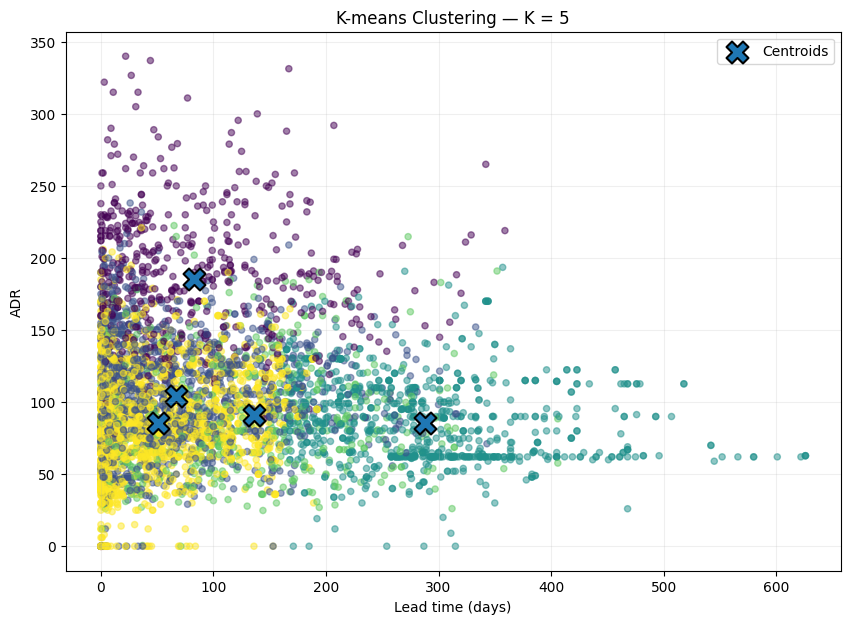

In [17]:
plot_data = cluster_data.sample(
    n=min(5000, len(cluster_data)),
    random_state=RANDOM_STATE
)

plt.figure(figsize=(10, 7))

plt.scatter(
    plot_data["lead_time"],
    plot_data["adr"],
    c=plot_data["cluster"],
    cmap="viridis",
    alpha=0.5,
    s=20
)

plt.scatter(
    centroids["lead_time"],
    centroids["adr"],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=1.5,
    label="Centroids"
)

plt.xlabel("Lead time (days)")
plt.ylabel("ADR")
plt.title(
    f"K-means Clustering — K = {best_k}"
)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

## 15. Post-clustering analysis — cancellation rate

The cancellation status was not used during clustering.

After the clusters have been created, `is_canceled` can be used as an external descriptive variable to examine whether the identified booking profiles have different cancellation rates.

This does not influence the clustering process.

In [18]:
if "is_canceled" in profile_data.columns:

    cancellation_profile = (
        profile_data
        .groupby("cluster")
        .agg(
            Number_of_bookings=(
                "is_canceled",
                "size"
            ),
            Cancellation_rate=(
                "is_canceled",
                "mean"
            )
        )
    )

    cancellation_profile[
        "Cancellation_rate (%)"
    ] = (
        cancellation_profile[
            "Cancellation_rate"
        ] * 100
    )

    cancellation_profile = (
        cancellation_profile.drop(
            columns="Cancellation_rate"
        )
    )

    display(
        cancellation_profile.round(2)
    )

else:
    print(
        "Column 'is_canceled' is not available."
    )

,Number_of_bookings,Cancellation_rate (%)
cluster,,
0,13217,40.76
1,30759,20.23
2,18893,63.85
3,11654,34.43
4,44682,36.94


In [19]:
if "hotel" in profile_data.columns:

    hotel_profile = pd.crosstab(
        profile_data["cluster"],
        profile_data["hotel"],
        normalize="index"
    ) * 100

    display(
        hotel_profile.round(2)
    )

hotel,City Hotel,Resort Hotel
cluster,,
0,57.50,42.50
1,69.83,30.17
2,79.08,20.92
3,27.19,72.81
4,71.55,28.45


In [20]:
final_summary = pd.DataFrame({
    "Measure": [
        "Selected algorithm",
        "Selected number of clusters",
        "Silhouette Score",
        "Number of observations",
        "Number of clustering features"
    ],
    "Value": [
        "K-means",
        best_k,
        round(best_silhouette, 4),
        len(cluster_data),
        len(features)
    ]
})

display(final_summary)

,Measure,Value
0,Selected algorithm,K-means
1,Selected number of clusters,5
2,Silhouette Score,0.2523
3,Number of observations,119205
4,Number of clustering features,5


# Final conclusions

K-means clustering was applied to identify groups of hotel bookings with similar characteristics.

Six different clustering solutions were evaluated for **K = 2 to K = 7**.

The number of clusters was evaluated using both the **Elbow Method** and the **Silhouette Score**.

The final model was selected based primarily on the Silhouette Score, while the Elbow Method was used as an additional graphical criterion.

The final clusters were interpreted using their centroids expressed in the original units of the selected variables.

The clustering was based on:

- booking lead time,
- average daily rate,
- total number of nights,
- total number of guests,
- number of special requests.

The cancellation variable was not used for clustering and was analysed only afterwards as an additional characteristic of the identified booking segments.